In [1]:
# ==========================================================
# CELL 151 — MACHINE LEARNING SETUP
# ==========================================================

import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Machine Learning environment loaded successfully.")

Machine Learning environment loaded successfully.


In [2]:
# ==========================================================
# CELL 152 — PROJECT PATHS
# ==========================================================

from pathlib import Path

# Notebook is expected to be inside:
# FIFA-World-Cup-Analytics/notebooks/

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

print("Project root:")
print(PROJECT_ROOT)

print("\nData directories:")
print("RAW      :", RAW_DIR)
print("INTERIM  :", INTERIM_DIR)
print("PROCESSED:", PROCESSED_DIR)

Project root:
c:\Users\AYUSH SINGH\OneDrive\Desktop\Dispersion\resume projects\FIFA-World-Cup-Analytics

Data directories:
RAW      : c:\Users\AYUSH SINGH\OneDrive\Desktop\Dispersion\resume projects\FIFA-World-Cup-Analytics\data\raw
INTERIM  : c:\Users\AYUSH SINGH\OneDrive\Desktop\Dispersion\resume projects\FIFA-World-Cup-Analytics\data\interim
PROCESSED: c:\Users\AYUSH SINGH\OneDrive\Desktop\Dispersion\resume projects\FIFA-World-Cup-Analytics\data\processed


In [3]:
# ==========================================================
# CELL 153 — AVAILABLE DATASETS
# ==========================================================

print("=" * 70)
print("INTERIM DATASETS")
print("=" * 70)

if INTERIM_DIR.exists():
    
    interim_files = sorted(INTERIM_DIR.glob("*.csv"))
    
    for file in interim_files:
        print("✓", file.name)

else:
    print("Interim directory not found.")


print("\n" + "=" * 70)
print("PROCESSED DATASETS")
print("=" * 70)

if PROCESSED_DIR.exists():
    
    processed_files = sorted(PROCESSED_DIR.glob("*.csv"))
    
    for file in processed_files:
        print("✓", file.name)

else:
    print("Processed directory not found.")

INTERIM DATASETS
✓ goalkeepers.csv
✓ matches_clean.csv
✓ outfield_players.csv
✓ players_clean.csv
✓ teams_clean.csv

PROCESSED DATASETS
✓ group_standings.csv
✓ matches.csv
✓ qualified_teams.csv
✓ stadiums_cleaned.csv


In [4]:
# ==========================================================
# CELL 154 — LOAD PLAYER DATA
# ==========================================================

possible_player_files = [
    INTERIM_DIR / "players_clean.csv",
    INTERIM_DIR / "players_cleaned.csv",
    INTERIM_DIR / "players.csv",
    PROCESSED_DIR / "players_clean.csv",
    PROCESSED_DIR / "players_cleaned.csv",
    PROCESSED_DIR / "players.csv",
]

player_file = None

for file in possible_player_files:
    if file.exists():
        player_file = file
        break

if player_file is None:
    raise FileNotFoundError(
        "Could not find the cleaned player dataset. "
        "Check data/interim and data/processed."
    )

players_ml = pd.read_csv(player_file)

print("Loaded file:")
print(player_file)

print("\nDataset shape:")
print(players_ml.shape)

display(players_ml.head())

Loaded file:
c:\Users\AYUSH SINGH\OneDrive\Desktop\Dispersion\resume projects\FIFA-World-Cup-Analytics\data\interim\players_clean.csv

Dataset shape:
(1248, 70)


,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,plus_minus_wowy,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,own_goals,gk_games,gk_games_starts,gk_minutes,gk_goals_against,gk_goals_against_per90,gk_shots_on_target_against,gk_saves,gk_save_pct,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,Achref Abada,Algeria,Algeria,DF,26,1999,Unknown Club,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0,0,0.0,4,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Adil Boulbina,Algeria,Algeria,FW,23,2003,Unknown Club,2,0,19.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,10.0,5.3,0.0,0,2,10.0,2,0.0,0.0,0.0,0.0,0.00,1.06,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,Algeria,FW,26,2000,Marseille,4,3,251.0,2.8,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.36,0.0,0.36,0.36,0.36,3.0,2.0,66.7,1.08,0.72,0.33,0.5,63.0,69.7,73.0,0,1,33.0,0,1.0,4.0,5.0,-1.0,-0.36,2.12,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Anis Hadj Moussa,Algeria,Algeria,MF,24,2002,Feyenoord,3,1,98.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,2.0,0.0,0.0,1.84,0.00,0.00,0.0,33.0,27.2,63.0,0,2,18.0,1,1.0,1.0,2.0,-1.0,-0.92,0.11,0.0,0.0,2.0,0.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aïssa Mandi,Algeria,Algeria,DF,34,1991,Lille,4,4,360.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,90.0,100.0,90.0,4,0,0.0,0,1.0,5.0,9.0,-4.0,-1.00,0.00,0.0,0.0,5.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# ==========================================================
# CELL 155 — PLAYER DATA STRUCTURE
# ==========================================================

print("=" * 70)
print("PLAYER DATASET STRUCTURE")
print("=" * 70)

print("Rows    :", players_ml.shape[0])
print("Columns :", players_ml.shape[1])

print("\nColumn names:")

for i, column in enumerate(players_ml.columns, start=1):
    print(f"{i:>3}. {column}")

PLAYER DATASET STRUCTURE
Rows    : 1248
Columns : 70

Column names:
  1. player
  2. team
  3. team_country
  4. position
  5. age
  6. birth_year
  7. club
  8. games
  9. games_starts
 10. minutes
 11. minutes_90s
 12. goals
 13. assists
 14. goals_assists
 15. goals_pens
 16. pens_made
 17. pens_att
 18. cards_yellow
 19. cards_red
 20. goals_per90
 21. assists_per90
 22. goals_assists_per90
 23. goals_pens_per90
 24. goals_assists_pens_per90
 25. shots
 26. shots_on_target
 27. shots_on_target_pct
 28. shots_per90
 29. shots_on_target_per90
 30. goals_per_shot
 31. goals_per_shot_on_target
 32. minutes_per_game
 33. minutes_pct
 34. minutes_per_start
 35. games_complete
 36. games_subs
 37. minutes_per_sub
 38. unused_subs
 39. points_per_game
 40. on_goals_for
 41. on_goals_against
 42. plus_minus
 43. plus_minus_per90
 44. plus_minus_wowy
 45. cards_yellow_red
 46. fouls
 47. fouled
 48. offsides
 49. crosses
 50. interceptions
 51. tackles_won
 52. own_goals
 53. gk_games
 54. g

In [6]:
# ==========================================================
# CELL 156 — NORMALIZE PLAYER POSITIONS
# ==========================================================

def get_primary_position(position):
    
    if pd.isna(position):
        return "Unknown"
    
    position = str(position).upper().strip()
    
    # Goalkeeper gets highest priority
    if "GK" in position:
        return "GK"
    
    # Defender
    if "DF" in position:
        return "DF"
    
    # Midfielder
    if "MF" in position:
        return "MF"
    
    # Forward
    if "FW" in position:
        return "FW"
    
    return "Unknown"


players_ml["primary_position"] = (
    players_ml["position"]
    .apply(get_primary_position)
)

print("Position distribution:")
display(
    players_ml["primary_position"]
    .value_counts()
    .to_frame("players")
)

Position distribution:


,players
primary_position,
MF,504
DF,430
FW,169
GK,145


In [7]:
# ==========================================================
# CELL 157 — SELECT CORE PERFORMANCE FEATURES
# ==========================================================

candidate_features = [
    "minutes",
    "minutes_90s",
    "games_starts",
    "goals",
    "assists",
    "goals_assists",
    "goals_per90",
    "assists_per90",
    "shots",
    "shots_on_target",
    "shots_per90",
    "shots_on_target_per90",
    "cards_yellow",
    "cards_red",
    "fouls",
    "fouled",
    "offsides",
    "crosses",
    "interceptions",
    "tackles_won",
    "own_goals"
]

available_features = [
    column
    for column in candidate_features
    if column in players_ml.columns
]

missing_features = [
    column
    for column in candidate_features
    if column not in players_ml.columns
]

print("=" * 70)
print("AVAILABLE FEATURES")
print("=" * 70)

for column in available_features:
    print("✓", column)

print("\n" + "=" * 70)
print("MISSING FEATURES")
print("=" * 70)

if missing_features:
    for column in missing_features:
        print("✗", column)
else:
    print("None")

AVAILABLE FEATURES
✓ minutes
✓ minutes_90s
✓ games_starts
✓ goals
✓ assists
✓ goals_assists
✓ goals_per90
✓ assists_per90
✓ shots
✓ shots_on_target
✓ shots_per90
✓ shots_on_target_per90
✓ cards_yellow
✓ cards_red
✓ fouls
✓ fouled
✓ offsides
✓ crosses
✓ interceptions
✓ tackles_won
✓ own_goals

MISSING FEATURES
None


In [8]:
# ==========================================================
# CELL 158 — BUILD PLAYER ML DATASET
# ==========================================================

identity_columns = [
    "player",
    "team",
    "primary_position"
]

ml_columns = identity_columns + available_features

player_ml = players_ml[
    ml_columns
].copy()

print("ML dataset shape:")
print(player_ml.shape)

display(player_ml.head())

ML dataset shape:
(1248, 24)


,player,team,primary_position,minutes,minutes_90s,games_starts,goals,assists,goals_assists,goals_per90,assists_per90,shots,shots_on_target,shots_per90,shots_on_target_per90,cards_yellow,cards_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,own_goals
0,Achref Abada,Algeria,DF,0.0,0.0,0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Adil Boulbina,Algeria,FW,19.0,0.2,0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,FW,251.0,2.8,3,1.0,0.0,1.0,0.36,0.0,3.0,2.0,1.08,0.72,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
3,Anis Hadj Moussa,Algeria,MF,98.0,1.1,1,0.0,0.0,0.0,0.00,0.0,2.0,0.0,1.84,0.00,0.0,0.0,0.0,2.0,0.0,5.0,1.0,0.0,0.0
4,Aïssa Mandi,Algeria,DF,360.0,4.0,4,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,5.0,0.0,0.0,4.0,3.0,0.0


In [9]:
# ==========================================================
# CELL 159 — CLEAN NUMERIC FEATURES
# ==========================================================

for column in available_features:
    
    player_ml[column] = pd.to_numeric(
        player_ml[column],
        errors="coerce"
    )

# Store missing-value counts BEFORE filling
missing_before = (
    player_ml[available_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("Missing values before treatment:")

display(
    missing_before[
        missing_before > 0
    ].to_frame("missing_count")
)

# For ML preparation, replace missing numeric values with 0
player_ml[available_features] = (
    player_ml[available_features]
    .fillna(0)
)

print("\nTotal missing numeric values after treatment:")

print(
    player_ml[available_features]
    .isna()
    .sum()
    .sum()
)

Missing values before treatment:


,missing_count



Total missing numeric values after treatment:
0


In [10]:
# ==========================================================
# CELL 160 — MINIMUM PARTICIPATION FILTER
# ==========================================================

before_filter = len(player_ml)

player_ml = player_ml[
    player_ml["minutes"] >= 90
].copy()

after_filter = len(player_ml)

removed_players = before_filter - after_filter

print("=" * 70)
print("PARTICIPATION FILTER")
print("=" * 70)

print("Players before filter :", before_filter)
print("Players after filter  :", after_filter)
print("Players removed       :", removed_players)

print("\nPosition distribution after filtering:")

display(
    player_ml["primary_position"]
    .value_counts()
    .to_frame("players")
)

print("\nTop players by minutes:")

display(
    player_ml[
        [
            "player",
            "team",
            "primary_position",
            "minutes"
        ]
    ]
    .sort_values(
        "minutes",
        ascending=False
    )
    .head(20)
)

PARTICIPATION FILTER
Players before filter : 1248
Players after filter  : 729
Players removed       : 519

Position distribution after filtering:


,players
primary_position,
MF,302
DF,273
FW,96
GK,58



Top players by minutes:


,player,team,primary_position,minutes
28,Emiliano Martínez,Argentina,GK,810.0
1057,Pau Cubarsí,Spain,DF,750.0
1061,Unai Simón,Spain,GK,750.0
1050,Marc Cucurella,Spain,DF,750.0
26,Alexis Mac Allister,Argentina,MF,750.0
41,Lionel Messi,Argentina,FW,740.0
1040,Aymeric Laporte,Spain,DF,727.0
1060,Rodri,Spain,MF,724.0
486,Mike Maignan,France,GK,720.0
477,Kylian Mbappé,France,FW,695.0


In [11]:
# ==========================================================
# CELL 161 — MACHINE LEARNING SETUP
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [12]:
# ==========================================================
# CELL 162 — LOAD MATCH DATA
# ==========================================================

BASE_DIR = Path("..")

matches_path = BASE_DIR / "data" / "interim" / "matches_clean.csv"

matches_ml = pd.read_csv(matches_path)

print("Dataset shape:", matches_ml.shape)

display(matches_ml.head())

Dataset shape: (104, 42)


,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,attendance,venue,referee,home_formation,away_formation,home_manager,away_manager,home_captain,away_captain,home_possession,away_possession,home_sot,away_sot,home_total_shots,away_total_shots,home_saves,away_saves,home_cards_yellow,away_cards_yellow,home_cards_red,away_cards_red,home_fouls,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1.0,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0,80824,"Estadio Banorte, Coyoacán",Wilton Sampaio,4-1-4-1,5-3-2,Javier Aguirre,Hugo Broos,César Montes,Ronwen Williams,61,40,4,2,16,3,2,2,1,2,1,2,12,11,3,1,12,8,8,7,1.0,1.0,Unknown
1,Group stage,1.0,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0,44985,"Estadio Akron, Zapopan",Amin Omar,3-4-3,3-4-3,Hong Myung-bo,Miroslav Koubek,Son Heung-min,Ladislav Krejčí,62,38,6,4,15,7,3,4,1,0,0,0,9,16,4,5,12,15,11,7,2.0,2.0,Unknown
2,Group stage,1.0,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0,43002,"BMO Field, Toronto",Facundo Tello,4-2-2-2,4-2-2-2,Jesse Marsch,Sergej Barbarez,Stephen Eustáquio,Sead Kolašinac,61,39,4,3,13,8,2,1,2,3,0,0,10,20,9,4,24,10,4,10,1.0,0.0,Unknown
3,Group stage,1.0,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0,70492,"SoFi Stadium, Inglewood",Danny Makkelie,4-2-3-1,4-2-2-2,Mauricio Pochettino,Gustavo Alfaro,Tim Ream,Gustavo Gómez,65,35,6,1,16,9,0,3,1,5,0,0,13,17,3,1,17,5,11,9,2.0,1.0,Unknown
4,Group stage,1.0,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0,67966,"Levi's Stadium, Santa Clara",Said Martínez,4-1-4-1,4-2-3-1,Julen Lopetegui,Murat Yakin,Boualem Khoukhi,Granit Xhaka,32,68,4,7,7,26,5,3,2,1,0,0,12,11,3,10,8,35,10,7,0.0,1.0,Unknown


In [13]:
# ==========================================================
# CELL 163 — CREATE TARGET VARIABLE
# ==========================================================

matches_ml["home_score"] = pd.to_numeric(
    matches_ml["home_score"],
    errors="coerce"
)

matches_ml["away_score"] = pd.to_numeric(
    matches_ml["away_score"],
    errors="coerce"
)

def get_result(row):
    if row["home_score"] > row["away_score"]:
        return "H"
    elif row["home_score"] < row["away_score"]:
        return "A"
    else:
        return "D"


matches_ml["match_result"] = matches_ml.apply(
    get_result,
    axis=1
)

print("Match result distribution:")
print(matches_ml["match_result"].value_counts())

display(
    matches_ml[
        [
            "home_team",
            "away_team",
            "home_score",
            "away_score",
            "match_result"
        ]
    ].head(10)
)

Match result distribution:
match_result
H    50
A    30
D    24
Name: count, dtype: int64


,home_team,away_team,home_score,away_score,match_result
0,Mexico,South Africa,2.0,0.0,H
1,Korea Republic,Czechia,2.0,1.0,H
2,Canada,Bosnia–Herz,1.0,1.0,D
3,United States,Paraguay,4.0,1.0,H
4,Qatar,Switzerland,1.0,1.0,D
5,Brazil,Morocco,1.0,1.0,D
6,Australia,Türkiye,2.0,0.0,H
7,Haiti,Scotland,0.0,1.0,A
8,Germany,Curaçao,7.0,1.0,H
9,Netherlands,Japan,2.0,2.0,D


In [14]:
# ==========================================================
# CELL 164 — CHRONOLOGICAL ORDER
# ==========================================================

matches_ml["date"] = pd.to_datetime(
    matches_ml["date"],
    errors="coerce"
)

matches_ml = matches_ml.sort_values(
    ["date", "start_time"],
    na_position="last"
).reset_index(drop=True)

matches_ml["match_number"] = np.arange(
    1,
    len(matches_ml) + 1
)

display(
    matches_ml[
        [
            "match_number",
            "date",
            "home_team",
            "away_team",
            "home_score",
            "away_score",
            "match_result"
        ]
    ].head(10)
)

,match_number,date,home_team,away_team,home_score,away_score,match_result
0,1,2026-06-11,Mexico,South Africa,2.0,0.0,H
1,2,2026-06-11,Korea Republic,Czechia,2.0,1.0,H
2,3,2026-06-12,Canada,Bosnia–Herz,1.0,1.0,D
3,4,2026-06-12,United States,Paraguay,4.0,1.0,H
4,5,2026-06-13,Qatar,Switzerland,1.0,1.0,D
5,6,2026-06-13,Brazil,Morocco,1.0,1.0,D
6,7,2026-06-13,Australia,Türkiye,2.0,0.0,H
7,8,2026-06-13,Haiti,Scotland,0.0,1.0,A
8,9,2026-06-14,Germany,Curaçao,7.0,1.0,H
9,10,2026-06-14,Netherlands,Japan,2.0,2.0,D


In [15]:
# ==========================================================
# CELL 165 — PRE-MATCH TEAM HISTORY
# ==========================================================

team_history = {}

def get_team_stats(team):
    if team not in team_history:
        team_history[team] = {
            "matches": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "points": 0
        }

    return team_history[team]


def calculate_features(team):

    stats = get_team_stats(team)

    matches_played = stats["matches"]

    if matches_played == 0:
        return {
            "matches": 0,
            "win_rate": 0,
            "draw_rate": 0,
            "loss_rate": 0,
            "avg_goals_for": 0,
            "avg_goals_against": 0,
            "points_per_game": 0,
            "goal_difference_per_game": 0
        }

    return {
        "matches": matches_played,

        "win_rate":
            stats["wins"] / matches_played,

        "draw_rate":
            stats["draws"] / matches_played,

        "loss_rate":
            stats["losses"] / matches_played,

        "avg_goals_for":
            stats["goals_for"] / matches_played,

        "avg_goals_against":
            stats["goals_against"] / matches_played,

        "points_per_game":
            stats["points"] / matches_played,

        "goal_difference_per_game":
            (
                stats["goals_for"] -
                stats["goals_against"]
            ) / matches_played
    }


feature_rows = []

for _, row in matches_ml.iterrows():

    home = row["home_team"]
    away = row["away_team"]

    home_stats = calculate_features(home)
    away_stats = calculate_features(away)

    feature_rows.append({

        "match_number": row["match_number"],

        "home_team": home,
        "away_team": away,

        # Home team
        "home_matches": home_stats["matches"],
        "home_win_rate": home_stats["win_rate"],
        "home_draw_rate": home_stats["draw_rate"],
        "home_loss_rate": home_stats["loss_rate"],
        "home_avg_goals_for": home_stats["avg_goals_for"],
        "home_avg_goals_against": home_stats["avg_goals_against"],
        "home_points_per_game": home_stats["points_per_game"],
        "home_goal_difference_per_game":
            home_stats["goal_difference_per_game"],

        # Away team
        "away_matches": away_stats["matches"],
        "away_win_rate": away_stats["win_rate"],
        "away_draw_rate": away_stats["draw_rate"],
        "away_loss_rate": away_stats["loss_rate"],
        "away_avg_goals_for": away_stats["avg_goals_for"],
        "away_avg_goals_against": away_stats["avg_goals_against"],
        "away_points_per_game": away_stats["points_per_game"],
        "away_goal_difference_per_game":
            away_stats["goal_difference_per_game"]
    })

    # ------------------------------------------------------
    # UPDATE HISTORY AFTER FEATURES ARE CREATED
    # ------------------------------------------------------

    home_stats_update = get_team_stats(home)
    away_stats_update = get_team_stats(away)

    home_goals = row["home_score"]
    away_goals = row["away_score"]

    home_stats_update["matches"] += 1
    away_stats_update["matches"] += 1

    home_stats_update["goals_for"] += home_goals
    home_stats_update["goals_against"] += away_goals

    away_stats_update["goals_for"] += away_goals
    away_stats_update["goals_against"] += home_goals

    if home_goals > away_goals:

        home_stats_update["wins"] += 1
        home_stats_update["points"] += 3

        away_stats_update["losses"] += 1

    elif home_goals < away_goals:

        away_stats_update["wins"] += 1
        away_stats_update["points"] += 3

        home_stats_update["losses"] += 1

    else:

        home_stats_update["draws"] += 1
        away_stats_update["draws"] += 1

        home_stats_update["points"] += 1
        away_stats_update["points"] += 1


pre_match_features = pd.DataFrame(feature_rows)

print("Feature dataset shape:", pre_match_features.shape)

display(pre_match_features.head())

Feature dataset shape: (104, 19)


,match_number,home_team,away_team,home_matches,home_win_rate,home_draw_rate,home_loss_rate,home_avg_goals_for,home_avg_goals_against,home_points_per_game,home_goal_difference_per_game,away_matches,away_win_rate,away_draw_rate,away_loss_rate,away_avg_goals_for,away_avg_goals_against,away_points_per_game,away_goal_difference_per_game
0,1,Mexico,South Africa,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Korea Republic,Czechia,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Canada,Bosnia–Herz,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,United States,Paraguay,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Qatar,Switzerland,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
# ==========================================================
# CELL 166 — DIFFERENCE FEATURES
# ==========================================================

pre_match_features["win_rate_diff"] = (
    pre_match_features["home_win_rate"]
    -
    pre_match_features["away_win_rate"]
)

pre_match_features["draw_rate_diff"] = (
    pre_match_features["home_draw_rate"]
    -
    pre_match_features["away_draw_rate"]
)

pre_match_features["avg_goals_for_diff"] = (
    pre_match_features["home_avg_goals_for"]
    -
    pre_match_features["away_avg_goals_for"]
)

pre_match_features["avg_goals_against_diff"] = (
    pre_match_features["home_avg_goals_against"]
    -
    pre_match_features["away_avg_goals_against"]
)

pre_match_features["points_per_game_diff"] = (
    pre_match_features["home_points_per_game"]
    -
    pre_match_features["away_points_per_game"]
)

pre_match_features["goal_difference_diff"] = (
    pre_match_features["home_goal_difference_per_game"]
    -
    pre_match_features["away_goal_difference_per_game"]
)

display(
    pre_match_features[
        [
            "home_team",
            "away_team",
            "win_rate_diff",
            "avg_goals_for_diff",
            "points_per_game_diff",
            "goal_difference_diff"
        ]
    ].head(10)
)

,home_team,away_team,win_rate_diff,avg_goals_for_diff,points_per_game_diff,goal_difference_diff
0,Mexico,South Africa,0.0,0.0,0.0,0.0
1,Korea Republic,Czechia,0.0,0.0,0.0,0.0
2,Canada,Bosnia–Herz,0.0,0.0,0.0,0.0
3,United States,Paraguay,0.0,0.0,0.0,0.0
4,Qatar,Switzerland,0.0,0.0,0.0,0.0
5,Brazil,Morocco,0.0,0.0,0.0,0.0
6,Australia,Türkiye,0.0,0.0,0.0,0.0
7,Haiti,Scotland,0.0,0.0,0.0,0.0
8,Germany,Curaçao,0.0,0.0,0.0,0.0
9,Netherlands,Japan,0.0,0.0,0.0,0.0


In [17]:
# ==========================================================
# CELL 167 — FINAL ML DATASET
# ==========================================================

ml_data = pre_match_features.merge(
    matches_ml[
        [
            "match_number",
            "date",
            "match_result"
        ]
    ],
    on="match_number",
    how="left"
)

print("Final ML dataset shape:", ml_data.shape)

display(ml_data.head())

print("\nTarget distribution:")
print(ml_data["match_result"].value_counts())

Final ML dataset shape: (104, 27)


,match_number,home_team,away_team,home_matches,home_win_rate,home_draw_rate,home_loss_rate,home_avg_goals_for,home_avg_goals_against,home_points_per_game,home_goal_difference_per_game,away_matches,away_win_rate,away_draw_rate,away_loss_rate,away_avg_goals_for,away_avg_goals_against,away_points_per_game,away_goal_difference_per_game,win_rate_diff,draw_rate_diff,avg_goals_for_diff,avg_goals_against_diff,points_per_game_diff,goal_difference_diff,date,match_result
0,1,Mexico,South Africa,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06-11,H
1,2,Korea Republic,Czechia,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06-11,H
2,3,Canada,Bosnia–Herz,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06-12,D
3,4,United States,Paraguay,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06-12,H
4,5,Qatar,Switzerland,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-06-13,D



Target distribution:
match_result
H    50
A    30
D    24
Name: count, dtype: int64


In [18]:
# ==========================================================
# CELL 168 — SELECT MODEL FEATURES
# ==========================================================

features = [
    "home_matches",
    "away_matches",

    "home_win_rate",
    "away_win_rate",

    "home_draw_rate",
    "away_draw_rate",

    "home_loss_rate",
    "away_loss_rate",

    "home_avg_goals_for",
    "away_avg_goals_for",

    "home_avg_goals_against",
    "away_avg_goals_against",

    "home_points_per_game",
    "away_points_per_game",

    "home_goal_difference_per_game",
    "away_goal_difference_per_game",

    "win_rate_diff",
    "draw_rate_diff",
    "avg_goals_for_diff",
    "avg_goals_against_diff",
    "points_per_game_diff",
    "goal_difference_diff"
]

X = ml_data[features].copy()
y = ml_data["match_result"].copy()

# Replace possible infinite values
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values
X = X.fillna(0)

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

Number of features: 22
X shape: (104, 22)
y shape: (104,)


,home_matches,away_matches,home_win_rate,away_win_rate,home_draw_rate,away_draw_rate,home_loss_rate,away_loss_rate,home_avg_goals_for,away_avg_goals_for,home_avg_goals_against,away_avg_goals_against,home_points_per_game,away_points_per_game,home_goal_difference_per_game,away_goal_difference_per_game,win_rate_diff,draw_rate_diff,avg_goals_for_diff,avg_goals_against_diff,points_per_game_diff,goal_difference_diff
0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# ==========================================================
# CELL 169 — CHRONOLOGICAL TRAIN / TEST SPLIT
# ==========================================================

split_index = int(len(X) * 0.75)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training matches:", len(X_train))
print("Testing matches:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training matches: 78
Testing matches: 26

Training target distribution:
match_result
H    36
D    22
A    20
Name: count, dtype: int64

Testing target distribution:
match_result
H    14
A    10
D     2
Name: count, dtype: int64


In [21]:
# ==========================================================
# CELL 170 — LOGISTIC REGRESSION
# ==========================================================

logistic_model = Pipeline(
    [
        (
            "scaler",
            StandardScaler()
        ),

        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)

# Train model
logistic_model.fit(
    X_train,
    y_train
)

# Make predictions
y_pred_logistic = logistic_model.predict(
    X_test
)

# Calculate accuracy
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print("=" * 70)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 70)

print(
    f"Accuracy: {accuracy_logistic:.3f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

LOGISTIC REGRESSION RESULTS
Accuracy: 0.308

Classification Report:
              precision    recall  f1-score   support

           A       0.50      0.10      0.17        10
           D       0.06      0.50      0.11         2
           H       0.86      0.43      0.57        14

    accuracy                           0.31        26
   macro avg       0.47      0.34      0.28        26
weighted avg       0.66      0.31      0.38        26



In [22]:
# ==========================================================
# CELL 171 — LOGISTIC REGRESSION BASELINE
# ==========================================================

print("=" * 70)
print("LOGISTIC REGRESSION BASELINE")
print("=" * 70)

print(f"Accuracy: {accuracy_logistic:.3f}")

print("\nDetailed Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

LOGISTIC REGRESSION BASELINE
Accuracy: 0.308

Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.50      0.10      0.17        10
           D       0.06      0.50      0.11         2
           H       0.86      0.43      0.57        14

    accuracy                           0.31        26
   macro avg       0.47      0.34      0.28        26
weighted avg       0.66      0.31      0.38        26



In [23]:
# ==========================================================
# CELL 172 — RANDOM FOREST
# ==========================================================

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest.predict(
    X_test
)

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("=" * 70)
print("RANDOM FOREST RESULTS")
print("=" * 70)

print(f"Accuracy: {accuracy_rf:.3f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

RANDOM FOREST RESULTS
Accuracy: 0.308

Classification Report:
              precision    recall  f1-score   support

           A       0.67      0.20      0.31        10
           D       0.07      0.50      0.12         2
           H       0.62      0.36      0.45        14

    accuracy                           0.31        26
   macro avg       0.45      0.35      0.29        26
weighted avg       0.60      0.31      0.37        26



In [24]:
# ==========================================================
# CELL 173 — XGBOOST
# ==========================================================

try:

    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    )

    # Convert labels to numeric
    label_mapping = {
        "A": 0,
        "D": 1,
        "H": 2
    }

    inverse_mapping = {
        0: "A",
        1: "D",
        2: "H"
    }

    y_train_xgb = y_train.map(label_mapping)

    xgb_model.fit(
        X_train,
        y_train_xgb
    )

    xgb_numeric_pred = xgb_model.predict(
        X_test
    )

    y_pred_xgb = pd.Series(
        xgb_numeric_pred,
        index=y_test.index
    ).map(inverse_mapping)

    accuracy_xgb = accuracy_score(
        y_test,
        y_pred_xgb
    )

    print("=" * 70)
    print("XGBOOST RESULTS")
    print("=" * 70)

    print(f"Accuracy: {accuracy_xgb:.3f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred_xgb,
            zero_division=0
        )
    )

    xgb_available = True

except ImportError:

    xgb_available = False

    accuracy_xgb = np.nan
    y_pred_xgb = None

    print("XGBoost is not installed.")
    print("Install it with:")
    print("pip install xgboost")

XGBoost is not installed.
Install it with:
pip install xgboost


In [25]:
# ==========================================================
# CELL 174 — MODEL COMPARISON
# ==========================================================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf,
        accuracy_xgb
    ]
})

model_results = model_results.sort_values(
    "Accuracy",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(model_results)

,Model,Accuracy
0,Logistic Regression,0.307692
1,Random Forest,0.307692
2,XGBoost,NaN


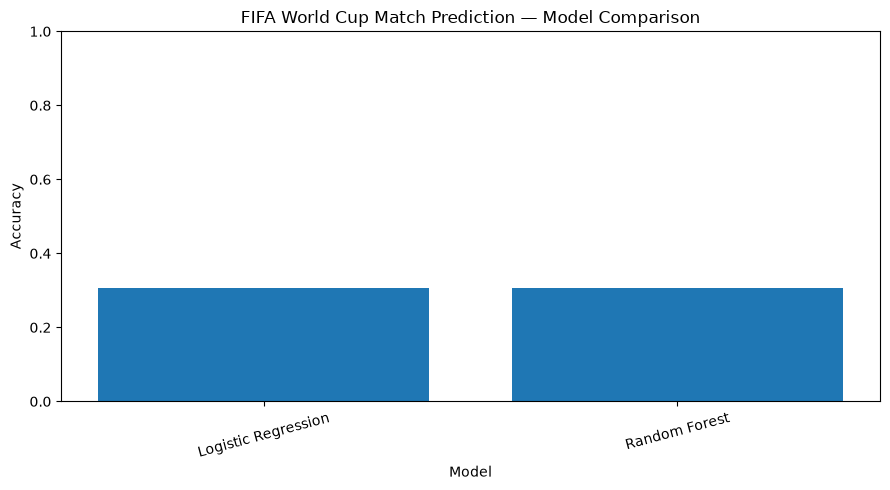

In [26]:
# ==========================================================
# CELL 175 — MODEL ACCURACY COMPARISON
# ==========================================================

plt.figure(figsize=(9, 5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.ylim(0, 1)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("FIFA World Cup Match Prediction — Model Comparison")

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

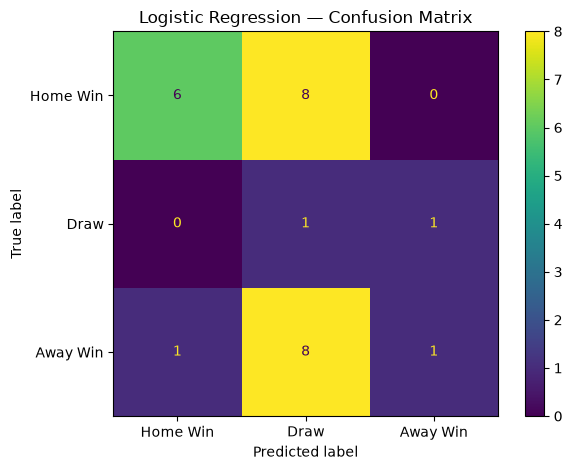

In [27]:
# ==========================================================
# CELL 176 — CONFUSION MATRIX: LOGISTIC REGRESSION
# ==========================================================

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["H", "D", "A"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=[
        "Home Win",
        "Draw",
        "Away Win"
    ]
)

disp.plot()

plt.title(
    "Logistic Regression — Confusion Matrix"
)

plt.tight_layout()

plt.show()

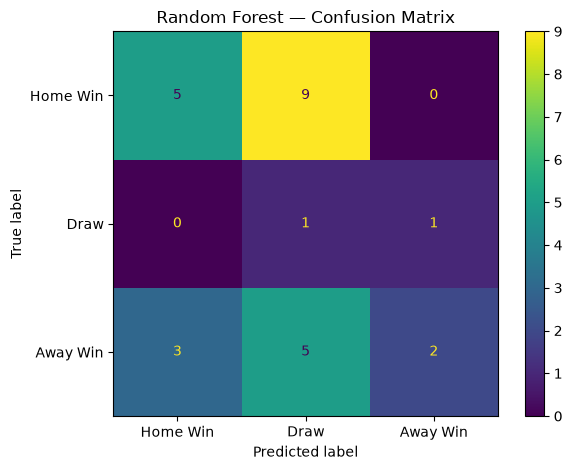

In [28]:
# ==========================================================
# CELL 177 — CONFUSION MATRIX: RANDOM FOREST
# ==========================================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["H", "D", "A"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "Home Win",
        "Draw",
        "Away Win"
    ]
)

disp.plot()

plt.title(
    "Random Forest — Confusion Matrix"
)

plt.tight_layout()

plt.show()

In [29]:
# ==========================================================
# CELL 178 — RANDOM FOREST FEATURE IMPORTANCE
# ==========================================================

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": random_forest.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top predictive features:")

display(
    feature_importance.head(15)
)

Top predictive features:


,feature,importance
0,goal_difference_diff,0.096006
1,home_goal_difference_per_game,0.095596
2,avg_goals_for_diff,0.091731
3,points_per_game_diff,0.078747
4,home_avg_goals_against,0.072199
5,avg_goals_against_diff,0.063549
6,away_avg_goals_for,0.055999
7,away_goal_difference_per_game,0.050953
8,home_avg_goals_for,0.045296
9,home_loss_rate,0.040471


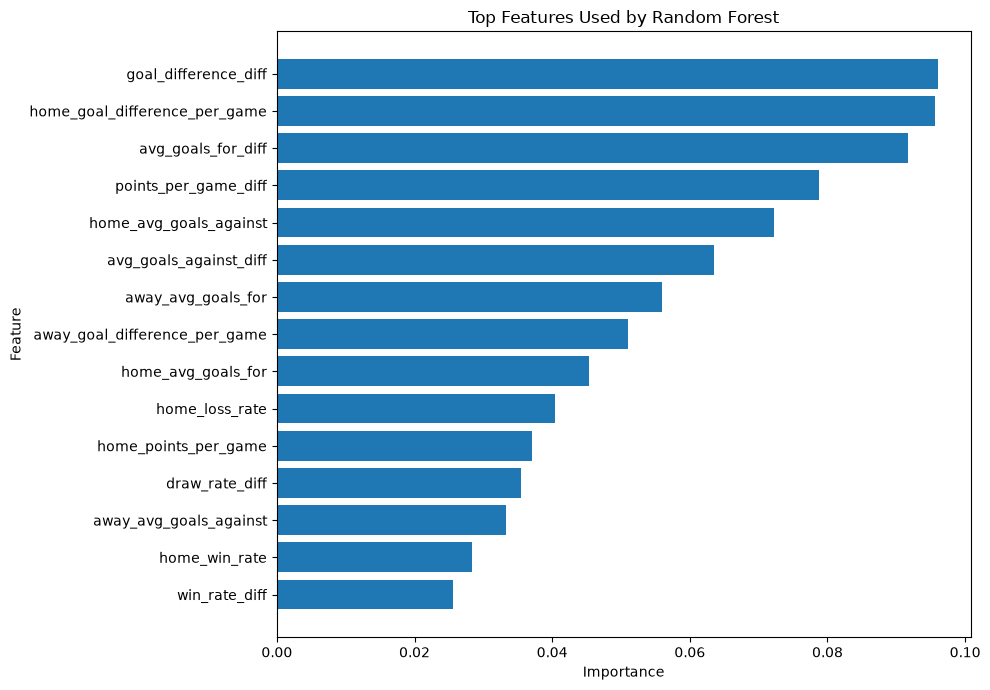

In [30]:
# ==========================================================
# CELL 179 — FEATURE IMPORTANCE VISUALIZATION
# ==========================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features Used by Random Forest"
)

plt.tight_layout()

plt.show()

In [31]:
# ==========================================================
# CELL 180 — PREDICTION PROBABILITIES
# ==========================================================

rf_probabilities = random_forest.predict_proba(
    X_test
)

rf_classes = random_forest.classes_

probability_columns = [
    f"prob_{cls}"
    for cls in rf_classes
]

prediction_probabilities = pd.DataFrame(
    rf_probabilities,
    columns=probability_columns,
    index=X_test.index
)

prediction_results = ml_data.loc[
    X_test.index,
    [
        "match_number",
        "date",
        "home_team",
        "away_team",
        "match_result"
    ]
].copy()

prediction_results["predicted_result"] = y_pred_rf

for column in probability_columns:
    prediction_results[column] = (
        prediction_probabilities[column]
    )

prediction_results["correct"] = (
    prediction_results["match_result"]
    ==
    prediction_results["predicted_result"]
)

display(
    prediction_results.head(20)
)

,match_number,date,home_team,away_team,match_result,predicted_result,prob_A,prob_D,prob_H,correct
78,79,2026-06-30,Mexico,Ecuador,H,H,0.143671,0.353901,0.502427,True
79,80,2026-07-01,England,Congo DR,H,D,0.130929,0.540278,0.328792,False
80,81,2026-07-01,Belgium,Senegal,H,D,0.194851,0.522765,0.282384,False
81,82,2026-07-01,United States,Bosnia–Herz,H,D,0.130950,0.654724,0.214326,False
82,83,2026-07-02,Spain,Austria,H,D,0.162687,0.537283,0.300030,False
83,84,2026-07-02,Portugal,Croatia,H,D,0.243769,0.412457,0.343774,False
84,85,2026-07-02,Switzerland,Algeria,H,D,0.075296,0.614695,0.310009,False
85,86,2026-07-03,Australia,Egypt,D,A,0.431963,0.275993,0.292044,False
86,87,2026-07-03,Argentina,Cabo Verde,H,H,0.227756,0.286662,0.485581,True
87,88,2026-07-03,Colombia,Ghana,H,D,0.148434,0.524248,0.327318,False


In [32]:
# ==========================================================
# CELL 180A — READABLE PREDICTION PROBABILITIES
# ==========================================================

for column in probability_columns:
    prediction_results[column] = (
        prediction_results[column] * 100
    ).round(2)

display(
    prediction_results[
        [
            "date",
            "home_team",
            "away_team",
            "match_result",
            "predicted_result",
            "prob_A",
            "prob_D",
            "prob_H",
            "correct"
        ]
    ].head(20)
)

,date,home_team,away_team,match_result,predicted_result,prob_A,prob_D,prob_H,correct
78,2026-06-30,Mexico,Ecuador,H,H,14.37,35.39,50.24,True
79,2026-07-01,England,Congo DR,H,D,13.09,54.03,32.88,False
80,2026-07-01,Belgium,Senegal,H,D,19.49,52.28,28.24,False
81,2026-07-01,United States,Bosnia–Herz,H,D,13.10,65.47,21.43,False
82,2026-07-02,Spain,Austria,H,D,16.27,53.73,30.00,False
83,2026-07-02,Portugal,Croatia,H,D,24.38,41.25,34.38,False
84,2026-07-02,Switzerland,Algeria,H,D,7.53,61.47,31.00,False
85,2026-07-03,Australia,Egypt,D,A,43.20,27.60,29.20,False
86,2026-07-03,Argentina,Cabo Verde,H,H,22.78,28.67,48.56,True
87,2026-07-03,Colombia,Ghana,H,D,14.84,52.42,32.73,False


In [33]:
# ==========================================================
# CELL 181 — SELECT BEST MODEL
# ==========================================================

model_scores = {
    "Logistic Regression": accuracy_logistic,
    "Random Forest": accuracy_rf
}

if xgb_available:
    model_scores["XGBoost"] = accuracy_xgb

best_model_name = max(
    model_scores,
    key=model_scores.get
)

best_accuracy = model_scores[best_model_name]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Model   :", best_model_name)
print("Accuracy:", round(best_accuracy, 3))

print("\nAll model scores:")

for model, score in model_scores.items():
    print(f"{model:<25} {score:.3f}")

BEST MODEL
Model   : Logistic Regression
Accuracy: 0.308

All model scores:
Logistic Regression       0.308
Random Forest             0.308


In [34]:
# ==========================================================
# CELL 182 — MODEL COMPARISON TABLE
# ==========================================================

comparison_table = pd.DataFrame(
    [
        {
            "Model": model,
            "Accuracy": score
        }
        for model, score in model_scores.items()
    ]
)

comparison_table["Accuracy (%)"] = (
    comparison_table["Accuracy"] * 100
).round(2)

comparison_table = comparison_table.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

display(comparison_table)

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.307692,30.77
1,Random Forest,0.307692,30.77


In [35]:
# ==========================================================
# CELL 183 — BEST MODEL PREDICTIONS
# ==========================================================

if best_model_name == "Logistic Regression":
    
    best_predictions = y_pred_logistic
    
elif best_model_name == "Random Forest":
    
    best_predictions = y_pred_rf
    
elif best_model_name == "XGBoost":
    
    best_predictions = y_pred_xgb


print("=" * 70)
print("BEST MODEL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

BEST MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A       0.50      0.10      0.17        10
           D       0.06      0.50      0.11         2
           H       0.86      0.43      0.57        14

    accuracy                           0.31        26
   macro avg       0.47      0.34      0.28        26
weighted avg       0.66      0.31      0.38        26



In [36]:
# ==========================================================
# CELL 184 — CORRECT VS INCORRECT PREDICTIONS
# ==========================================================

analysis_results = ml_data.loc[
    X_test.index,
    [
        "match_number",
        "date",
        "home_team",
        "away_team",
        "match_result"
    ]
].copy()

analysis_results["predicted_result"] = (
    best_predictions
)

analysis_results["correct"] = (
    analysis_results["match_result"]
    ==
    analysis_results["predicted_result"]
)

print("=" * 70)
print("PREDICTION SUMMARY")
print("=" * 70)

print(
    "Correct predictions:",
    analysis_results["correct"].sum()
)

print(
    "Incorrect predictions:",
    (~analysis_results["correct"]).sum()
)

print(
    "Total predictions:",
    len(analysis_results)
)

display(analysis_results)

PREDICTION SUMMARY
Correct predictions: 8
Incorrect predictions: 18
Total predictions: 26


,match_number,date,home_team,away_team,match_result,predicted_result,correct
78,79,2026-06-30,Mexico,Ecuador,H,H,True
79,80,2026-07-01,England,Congo DR,H,H,True
80,81,2026-07-01,Belgium,Senegal,H,H,True
81,82,2026-07-01,United States,Bosnia–Herz,H,D,False
82,83,2026-07-02,Spain,Austria,H,H,True
83,84,2026-07-02,Portugal,Croatia,H,H,True
84,85,2026-07-02,Switzerland,Algeria,H,D,False
85,86,2026-07-03,Australia,Egypt,D,A,False
86,87,2026-07-03,Argentina,Cabo Verde,H,D,False
87,88,2026-07-03,Colombia,Ghana,H,H,True


In [37]:
# ==========================================================
# CELL 185 — INCORRECT PREDICTIONS
# ==========================================================

incorrect_predictions = analysis_results[
    analysis_results["correct"] == False
].copy()

print("=" * 70)
print("INCORRECT PREDICTIONS")
print("=" * 70)

print(
    "Number of incorrect predictions:",
    len(incorrect_predictions)
)

display(
    incorrect_predictions[
        [
            "date",
            "home_team",
            "away_team",
            "match_result",
            "predicted_result"
        ]
    ]
)

INCORRECT PREDICTIONS
Number of incorrect predictions: 18


,date,home_team,away_team,match_result,predicted_result
81,2026-07-01,United States,Bosnia–Herz,H,D
84,2026-07-02,Switzerland,Algeria,H,D
85,2026-07-03,Australia,Egypt,D,A
86,2026-07-03,Argentina,Cabo Verde,H,D
88,2026-07-04,Canada,Morocco,A,D
90,2026-07-05,Brazil,Norway,A,D
91,2026-07-05,Mexico,England,A,D
92,2026-07-06,Portugal,Spain,A,H
93,2026-07-06,United States,Belgium,A,D
94,2026-07-07,Argentina,Egypt,H,D


In [38]:
# ==========================================================
# CELL 186 — ACCURACY BY MATCH RESULT
# ==========================================================

result_analysis = []

for result in ["H", "D", "A"]:
    
    subset = analysis_results[
        analysis_results["match_result"] == result
    ]
    
    if len(subset) > 0:
        
        accuracy = (
            subset["correct"].mean()
        )
        
    else:
        
        accuracy = np.nan
    
    result_analysis.append(
        {
            "Actual Result": result,
            "Matches": len(subset),
            "Accuracy": accuracy
        }
    )

result_analysis = pd.DataFrame(
    result_analysis
)

result_analysis["Accuracy (%)"] = (
    result_analysis["Accuracy"] * 100
).round(2)

display(result_analysis)

,Actual Result,Matches,Accuracy,Accuracy (%)
0,H,14,0.428571,42.86
1,D,2,0.500000,50.00
2,A,10,0.100000,10.00


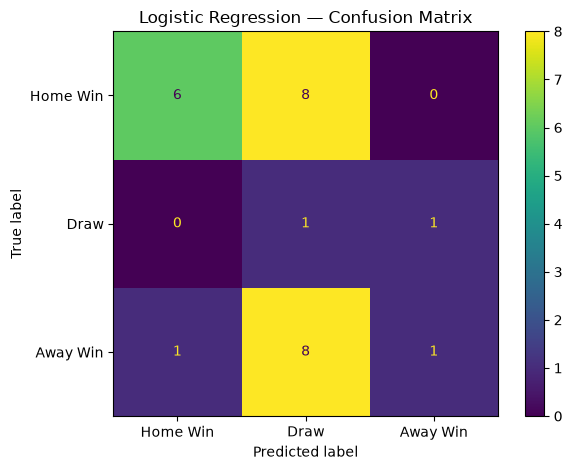

In [39]:
# ==========================================================
# CELL 187 — BEST MODEL CONFUSION MATRIX
# ==========================================================

cm_best = confusion_matrix(
    y_test,
    best_predictions,
    labels=["H", "D", "A"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=[
        "Home Win",
        "Draw",
        "Away Win"
    ]
)

disp.plot()

plt.title(
    f"{best_model_name} — Confusion Matrix"
)

plt.tight_layout()

plt.show()

In [40]:
# ==========================================================
# CELL 188 — SAVE PREDICTION RESULTS
# ==========================================================

output_dir = Path("../data/processed")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

prediction_output = output_dir / (
    "match_prediction_results.csv"
)

analysis_results.to_csv(
    prediction_output,
    index=False
)

print("Saved:")
print(prediction_output)

Saved:
..\data\processed\match_prediction_results.csv


In [41]:
# ==========================================================
# CELL 189 — SAVE MODEL COMPARISON
# ==========================================================

comparison_output = output_dir / (
    "model_comparison.csv"
)

comparison_table.to_csv(
    comparison_output,
    index=False
)

result_output = output_dir / (
    "accuracy_by_match_result.csv"
)

result_analysis.to_csv(
    result_output,
    index=False
)

print("Saved files:")

print(comparison_output)
print(result_output)

Saved files:
..\data\processed\model_comparison.csv
..\data\processed\accuracy_by_match_result.csv


In [42]:
# ==========================================================
# CELL 190 — FINAL ML SUMMARY
# ==========================================================

total_test_matches = len(y_test)

correct_predictions = (
    analysis_results["correct"].sum()
)

incorrect_predictions = (
    total_test_matches -
    correct_predictions
)

print("=" * 75)
print("FIFA WORLD CUP ANALYTICS — MACHINE LEARNING SUMMARY")
print("=" * 75)

print(f"Total matches used for testing : {total_test_matches}")
print(f"Correct predictions            : {correct_predictions}")
print(f"Incorrect predictions          : {incorrect_predictions}")

print(
    f"Best model                     : {best_model_name}"
)

print(
    f"Best model accuracy            : "
    f"{best_accuracy * 100:.2f}%"
)

print("\nModel comparison:")

display(comparison_table)

print("\nInterpretation:")
print(
    "The models were evaluated using a chronological "
    "train/test split so that future match information "
    "was not used to predict earlier matches."
)

print(
    "The results should be interpreted cautiously because "
    "the FIFA World Cup provides a relatively small number "
    "of matches for machine-learning evaluation."
)

print(
    "The model is therefore presented as a sports analytics "
    "demonstration rather than a production-grade prediction system."
)

FIFA WORLD CUP ANALYTICS — MACHINE LEARNING SUMMARY
Total matches used for testing : 26
Correct predictions            : 8
Incorrect predictions          : 18
Best model                     : Logistic Regression
Best model accuracy            : 30.77%

Model comparison:


,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.307692,30.77
1,Random Forest,0.307692,30.77



Interpretation:
The models were evaluated using a chronological train/test split so that future match information was not used to predict earlier matches.
The results should be interpreted cautiously because the FIFA World Cup provides a relatively small number of matches for machine-learning evaluation.
The model is therefore presented as a sports analytics demonstration rather than a production-grade prediction system.
